##### ARTI 560 - Computer Vision

## Object Detection Using YOLOV8 with KerasCV - Exercise 

### Objective

In this exercise, you wil learn how to use the pre-trained YOLOV8 model from KerasCV to detect objects in images.

You will:

1. Load the pre-trained YOLOV8 model from KerasCV using the [Pascal VOC preset](https://www.kaggle.com/models/keras/yolov8)

2. Load 5 images for different classes in [Pascal VOC 2012 dataset](https://datasetninja.com/pascal-voc-2012) and convert it into a NumPy array suitable for the model.

3. Resize the images before inference to match the model’s expected input size using:
    ```
    inference_resizing = keras_cv.layers.Resizing(
        640, 640, pad_to_aspect_ratio=True, bounding_box_format="xywh"
    )
    ```

    **Note:** Resizing ensures that the images fit the model input, maintains aspect ratio, and correctly adjusts bounding boxes.

4. Run the YOLOV8 detector on each image to predict bounding boxes, class labels, and confidence scores.

5. Visualize the predictions by drawing the bounding boxes and labels on the images.

6. Record for each image:

    - Which objects were detected correctly

    - The confidence scores of the detections

    - Any missed or incorrectly labeled objects

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [3]:
!pip install keras-cv -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 650.7/650.7 kB 10.7 MB/s eta 0:00:00 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 950.8/950.8 kB 35.9 MB/s eta 0:00:00


In [4]:
import os
import numpy as np
import tensorflow as tf
from tensorflow import keras
import keras_cv
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
from PIL import Image, ImageDraw

In [5]:
class_names = [
    "aeroplane", "bicycle", "bird", "boat", "bottle",
    "bus", "car", "cat", "chair", "cow",
    "diningtable", "dog", "horse", "motorbike", "person",
    "pottedplant", "sheep", "sofa", "train", "tvmonitor"
]

In [7]:
# Load YOLOV8 Model
detector = keras_cv.models.YOLOV8Detector.from_preset(
    "yolo_v8_m_pascalvoc",
    bounding_box_format="xywh"
)

In [8]:
# Resizing Layer
inference_resizing = keras_cv.layers.Resizing(
    640, 640, pad_to_aspect_ratio=True, bounding_box_format="xywh"
)

In [9]:
# Image Paths
image_info = [
    {
        "file_name": "dog.jpg",
        "path": "/content/drive/MyDrive/Lab 4/images/dog.jpg",
        "true_objects": ["dog"]
    },
    {
        "file_name": "car.jpg",
        "path": "/content/drive/MyDrive/Lab 4/images/car.jpg",
        "true_objects": ["car"]
    },
    {
        "file_name": "person.jpg",
        "path": "/content/drive/MyDrive/Lab 4/images/person.jpg",
        "true_objects": ["person"]
    },
    {
        "file_name": "bicycle.jpg",
        "path": "/content/drive/MyDrive/Lab 4/images/bicycle.jpg",
        "true_objects": ["bicycle"]
    },
    {
        "file_name": "bus.jpg",
        "path": "/content/drive/MyDrive/Lab 4/images/bus.jpg",
        "true_objects": ["bus"]
    }
]

In [10]:
for item in image_info:
    print(item["path"], os.path.exists(item["path"]))

/content/drive/MyDrive/Lab 4/images/dog.jpg True
/content/drive/MyDrive/Lab 4/images/car.jpg True
/content/drive/MyDrive/Lab 4/images/person.jpg True
/content/drive/MyDrive/Lab 4/images/bicycle.jpg True
/content/drive/MyDrive/Lab 4/images/bus.jpg True


In [11]:
# Helper Functions
def load_image_array(path):
    image = keras.utils.load_img(path)
    image = keras.utils.img_to_array(image)
    return image.astype("float32")

def detect_objects(image_array, confidence_threshold=0.3):
    resized = inference_resizing(tf.expand_dims(image_array, axis=0))
    predictions = detector.predict(resized, verbose=0)

    boxes = predictions["boxes"][0]
    classes = predictions["classes"][0].astype("int32")
    confidences = predictions["confidence"][0]

    valid = confidences >= confidence_threshold

    boxes = boxes[valid]
    classes = classes[valid]
    confidences = confidences[valid]

    detected_labels = [class_names[int(c)] for c in classes]

    return boxes, classes, confidences, detected_labels

def draw_predictions(image_array, boxes, classes, confidences):
    image = Image.fromarray(image_array.astype("uint8"))
    draw = ImageDraw.Draw(image)

    for box, cls, score in zip(boxes, classes, confidences):
        x, y, w, h = box
        x1 = int(x)
        y1 = int(y)
        x2 = int(x + w)
        y2 = int(y + h)

        label = f"{class_names[int(cls)]}: {score:.2f}"

        draw.rectangle([x1, y1, x2, y2], outline="red", width=3)
        draw.text((x1, max(0, y1 - 12)), label, fill="red")

    return np.array(image)

In [12]:
# Detection on All Images
all_results = []
visualization_images = []

for item in image_info:
    image_array = load_image_array(item["path"])
    boxes, classes, confidences, detected_labels = detect_objects(image_array, confidence_threshold=0.3)
    visualized = draw_predictions(image_array, boxes, classes, confidences)

    true_objects = item["true_objects"]
    detected_set = set(detected_labels)
    true_set = set(true_objects)

    correct_detected = [obj for obj in true_objects if obj in detected_set]
    missed_objects = [obj for obj in true_objects if obj not in detected_set]
    incorrect_labels = [label for label in detected_labels if label not in true_set]

    confidence_text = ", ".join([f"{label} ({score:.2f})" for label, score in zip(detected_labels, confidences)])

    all_results.append({
        "Image File": item["file_name"],
        "Detected Objects": ", ".join(detected_labels) if detected_labels else "None",
        "Correctly Detected": ", ".join(correct_detected) if correct_detected else "None",
        "Confidence Scores": confidence_text if confidence_text else "None",
        "Missed Objects": ", ".join(missed_objects) if missed_objects else "None",
        "Incorrect Labels": ", ".join(incorrect_labels) if incorrect_labels else "None"
    })

    visualization_images.append((item["file_name"], visualized))

In [13]:
results_df = pd.DataFrame(all_results)
print(results_df.to_string(index=False))

 Image File               Detected Objects Correctly Detected                                          Confidence Scores Missed Objects Incorrect Labels
    dog.jpg                            dog                dog                                                 dog (0.98)           None             None
    car.jpg                            car                car                                                 car (0.99)           None             None
 person.jpg person, person, person, person             person person (0.98), person (0.97), person (0.97), person (0.92)           None             None
bicycle.jpg                        bicycle            bicycle                                             bicycle (0.98)           None             None
    bus.jpg                            bus                bus                                                 bus (0.90)           None             None


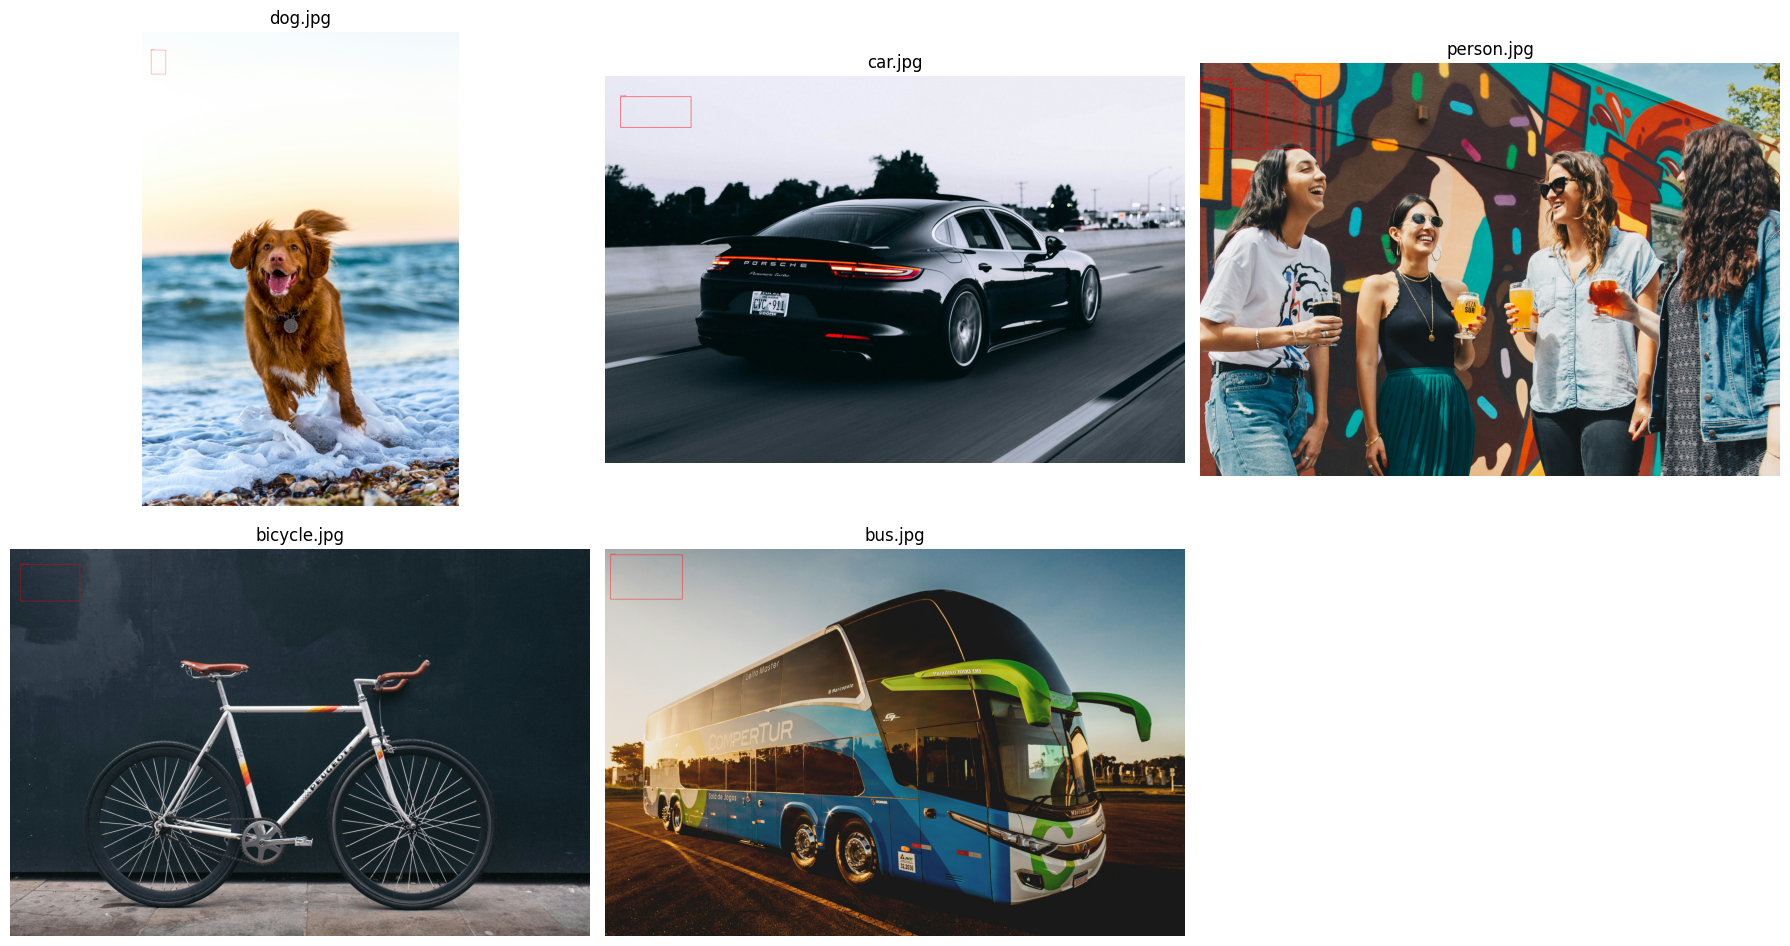

In [14]:
plt.figure(figsize=(18, 10))
for i, (file_name, vis_image) in enumerate(visualization_images):
    plt.subplot(2, 3, i + 1)
    plt.imshow(vis_image.astype("uint8"))
    plt.title(file_name)
    plt.axis("off")

plt.tight_layout()
plt.show()

In [15]:
for row in all_results:
    print("Image File:", row["Image File"])
    print("Detected Objects:", row["Detected Objects"])
    print("Correctly Detected:", row["Correctly Detected"])
    print("Confidence Scores:", row["Confidence Scores"])
    print("Missed Objects:", row["Missed Objects"])
    print("Incorrect Labels:", row["Incorrect Labels"])
    print("-" * 60)

Image File: dog.jpg
Detected Objects: dog
Correctly Detected: dog
Confidence Scores: dog (0.98)
Missed Objects: None
Incorrect Labels: None
------------------------------------------------------------
Image File: car.jpg
Detected Objects: car
Correctly Detected: car
Confidence Scores: car (0.99)
Missed Objects: None
Incorrect Labels: None
------------------------------------------------------------
Image File: person.jpg
Detected Objects: person, person, person, person
Correctly Detected: person
Confidence Scores: person (0.98), person (0.97), person (0.97), person (0.92)
Missed Objects: None
Incorrect Labels: None
------------------------------------------------------------
Image File: bicycle.jpg
Detected Objects: bicycle
Correctly Detected: bicycle
Confidence Scores: bicycle (0.98)
Missed Objects: None
Incorrect Labels: None
------------------------------------------------------------
Image File: bus.jpg
Detected Objects: bus
Correctly Detected: bus
Confidence Scores: bus (0.90)
Mis